# Comparaison de modèles de prévision de la demande pour la supply chain (régression)

## Introduction

Dans ce notebook, nous allons commencer à essayer de répondre au besoin du persona de Sophie Martin, c'est à dire anticiper la demande afin d'éviter les ruptures de stock. Nous allons comparer différents modèles pour choisir le plus adapté pour prédire les ventes.

---

## Préparation des données

Dans cette première partie, nous allons transformer nos données pour que le modèle puisse apprendre. On a actuellement un dataset où une colonne = un jour, mais il est préférable d'avoir une ligne = une observation. Puis, on sommes toutes les ventes par jours puisqu'on cherche ici à prédire le nombre de ventes des prochains jours.

In [7]:
import pandas as pd
import numpy as np

# Chargement des données 
sales = pd.read_csv("/Users/lisaroubertie/Desktop/Cours/Inge2/S2/ProjetApplication/OptimisationPredictive_ChaineLogistique/datas/sales_train_evaluation.csv")
calendar = pd.read_csv("/Users/lisaroubertie/Desktop/Cours/Inge2/S2/ProjetApplication/OptimisationPredictive_ChaineLogistique/datas/calendar.csv")

# Transformation des colonnes en une ligne par jour
sales = sales.melt(
    id_vars=["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"],
    var_name="d", value_name="sales")

# Merge avec le calendrier pour avoir les dates
df = sales.merge(calendar, on="d", how="left")
df["date"] = pd.to_datetime(df["date"])

# Somme de toutes les ventes par jours
daily = df.groupby("date")["sales"].sum().reset_index()

---

## Contexte temporel pour le modèle

Le but de cette partie est de donner un contexte temporel au modèle comme le jour, ce qu'on vendait hier etc. On ajoute donc des colonnes à notre dataset avec ces informations.

In [8]:
# Dates
daily["dayofweek"] = daily["date"].dt.dayofweek # lundi=0 et dimanche=6
daily["month"] = daily["date"].dt.month

# Lags (pour les séries temporelles)
daily["lag_1"] = daily["sales"].shift(1) # Les ventes d'hier
daily["lag_7"] = daily["sales"].shift(7) # Les ventes d'il y a une semaine
daily["lag_28"] = daily["sales"].shift(28) # Les ventes du mois dernier

# Moyenne et ecart type des 7 derniers jours
daily["rolling_mean_7"] = daily["sales"].shift(1).rolling(7).mean()
daily["rolling_std_7"]  = daily["sales"].shift(1).rolling(7).std()

# Premières lignes sans passé donc il faut les supprimer
daily = daily.dropna()

print(daily.shape)
print(daily.isna().sum())

(1913, 9)
date              0
sales             0
dayofweek         0
month             0
lag_1             0
lag_7             0
lag_28            0
rolling_mean_7    0
rolling_std_7     0
dtype: int64


---

## Train-Test-Split

Il serait mauvais pour le modèle de faire un simple train_test_split(X, y) parce qu'il mélangerait les dates et verrait le futur. Il faut couper dans le temps : passé = entrainement et futur = test. Ici, on entraine sur tout et on testera sur les 28 derniers jours. Les features sont les ventes précédentes (jour, mois, semaine...) et nous cherchons à prédire les ventes.

In [10]:
features = [
    "dayofweek", 
    "month",
    "lag_1", 
    "lag_7", 
    "lag_28",
    "rolling_mean_7", 
    "rolling_std_7"]

X = daily[features]
y = daily["sales"]

# Découpage dans le temps avce 80% pour entrainer et 20% pour tester
# On ne peut pas faire de mélange aléatoire comme en ML, sinon le modèle voit le futur
split = int(len(X) * 0.8)
X_train = X.iloc[:split]
X_test = X.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

# Vérification des tailles
print("Train :", X_train.shape, "| Test :", X_test.shape)
print("Période train :", daily["date"].iloc[0].date(), "au", daily["date"].iloc[split-1].date())
print("Période test  :", daily["date"].iloc[split].date(), "au", daily["date"].iloc[-1].date())

Train : (1530, 7) | Test : (383, 7)
Période train : 2011-02-26 au 2015-05-05
Période test  : 2015-05-06 au 2016-05-22


---

## Modèle baseline naïf

In [11]:
# on prédit qu'on vendra exactement pareil aujourd'hui qu'il y a 7 jours
from sklearn.metrics import mean_squared_error

pred_naif = X_test["lag_7"].values
rmse_naif = np.sqrt(mean_squared_error(y_test, pred_naif))
print("RMSE Modèle naïf :", round(rmse_naif, 2))

RMSE Modèle naïf : 5053.01


On va utiliser un modèle naïf qui prédit que les ventes de demain seront identiques à celles d'il y a 7 jours. Il obtient un RMSE de 5053.01, qui sera notre référence. Si les modèles suivants sont moins bien, ça veut dire qu'ils n'apportent pas de valeurs ajoutées.

---

## Modèle 1 - Régression linéaire

RMSE Régression Linéaire :  3612.06


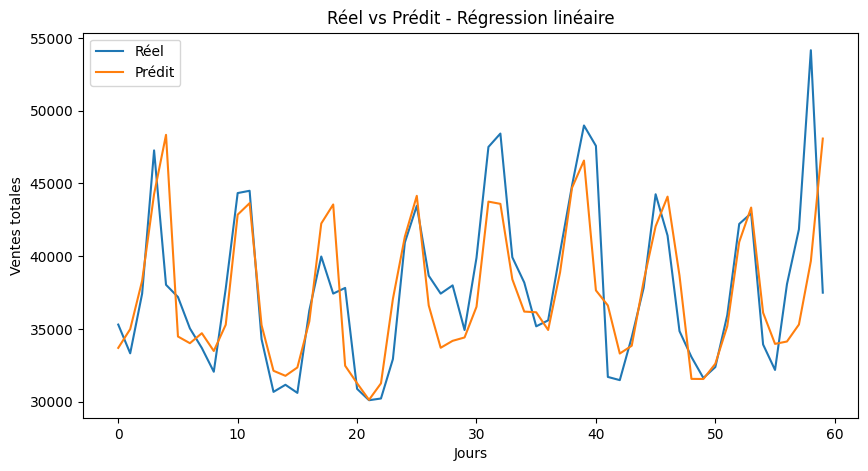

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

rl = LinearRegression()
rl.fit(X_train, y_train)
pred_rl = rl.predict(X_test)

rmse_rl = np.sqrt(mean_squared_error(y_test, pred_rl))
print("RMSE Régression Linéaire : ", round(rmse_rl, 2))

# Visualisation sur 60 jours
plt.figure(figsize=(10,5))
plt.plot(y_test.values[:60], label="Réel")
plt.plot(pred_rl[:60], label="Prédit")
plt.title("Réel vs Prédit - Régression linéaire")
plt.xlabel("Jours")
plt.ylabel("Ventes totales")
plt.legend()
plt.show()

En régression linéaire, le score RMSE (3612 ventes) est plutôt bon : il suit globalement bien la tendance des ventes. Le modèle est donc plutôt efficace dans notre contexte, et surtout, il dépasse la baseline naïve il faut maintenant le comparer avec les autres.

---

## Modèle 2 - Random Forest

Ce modèle est normalement plus précis car il est capable de capturer les relations non linéaires. Il devrait donc mieux capter les variations

RMSE Random Forest : 3768.89


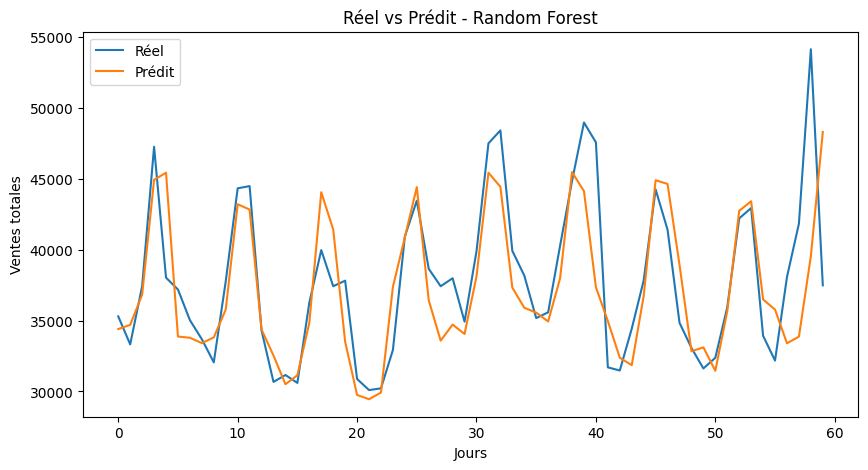

In [13]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
print("RMSE Random Forest :", round(rmse_rf, 2))

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:60], label="Réel")
plt.plot(pred_rf[:60], label="Prédit")
plt.title("Réel vs Prédit - Random Forest")
plt.xlabel("Jours")
plt.ylabel("Ventes totales")
plt.legend()
plt.show()

Le Random Forest (avec 200 arbres) arrive à capturer certains pics de demande mais a une performance légèrement plus faible que la régression linéaire, avec un RMSE de 3768.89. 

---

### Importance des features

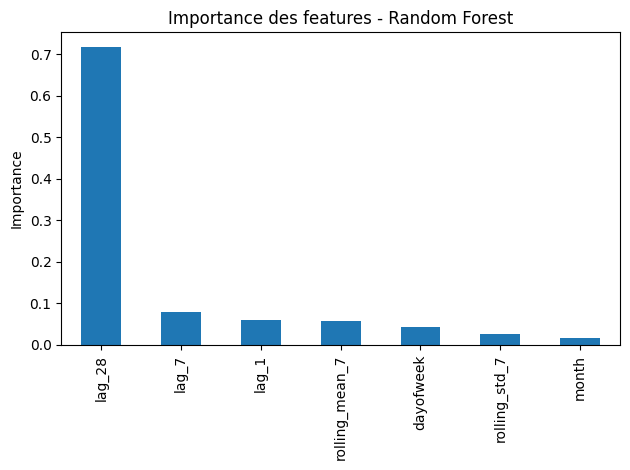

In [14]:
importanceFeatures = pd.Series(rf.feature_importances_, index=features)
importanceFeatures = importanceFeatures.sort_values(ascending=False)

importanceFeatures.plot(kind="bar")
plt.title("Importance des features - Random Forest")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

Le graphe d'importance des features montre que le lag_28 est de loin la plus importante pour la prédiction. Les autres sont très secondaire et quasi nul (pour month par exemple)

---

## Modèle 3 - XGBoost

XGBoost est un modèle de boosting basé sur les arbres. Nous espérons donc qu'il offre de meilleures performances que les modèles pécédents.

In [10]:
import xgboost
print(xgboost.__version__)

2.0.3


RMSE XGBoost : 3943.28


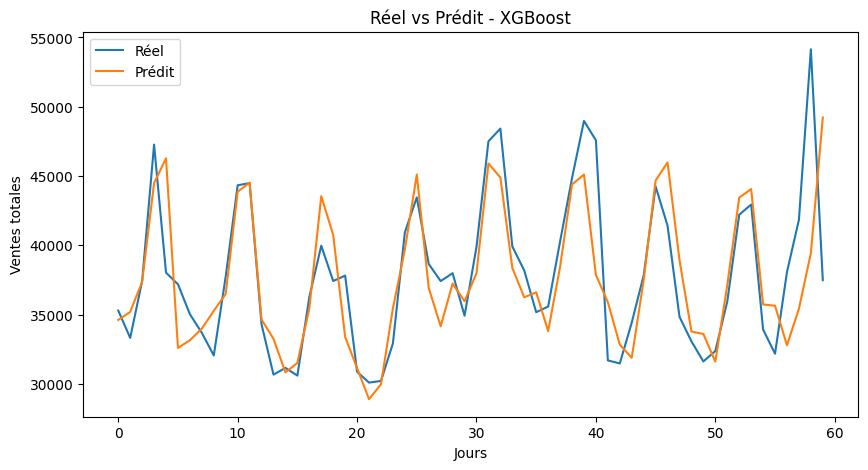

In [15]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

xgb = XGBRegressor(
    n_estimators=100,   # nombre d’arbres
    max_depth=6,        # profondeur des arbres
    random_state=42)
xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
print("RMSE XGBoost :", round(rmse_xgb, 2))

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:60], label="Réel")
plt.plot(pred_xgb[:60], label="Prédit")
plt.title("Réel vs Prédit - XGBoost")
plt.xlabel("Jours")
plt.ylabel("Ventes totales")
plt.legend()
plt.show()

XGBoost obtient un RMSE de 3943.28, ce qui est moins bon que les 2 modèles précédents.

---

## Modèle 4 - MLP

RMSE MLP : 3656.65


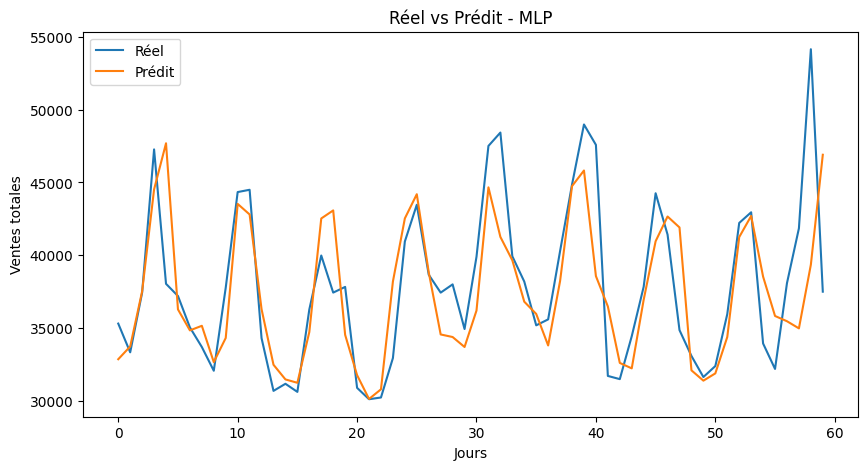

In [16]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

mlp = MLPRegressor(
    hidden_layer_sizes=(50, 50),  # 2 couches de 50 neurones
    activation='relu',
    max_iter=200,
    random_state=42)
mlp.fit(X_train, y_train)
pred_mlp = mlp.predict(X_test)

rmse_mlp = np.sqrt(mean_squared_error(y_test, pred_mlp))
print("RMSE MLP :", round(rmse_mlp, 2))

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:60], label="Réel")
plt.plot(pred_mlp[:60], label="Prédit")
plt.title("Réel vs Prédit - MLP")
plt.xlabel("Jours")
plt.ylabel("Ventes totales")
plt.legend()
plt.show()

Le MLP obtient un RMSE de 3656.65, ce qui atteint quasiment le niveau de la régression linéaire. 

---

## Conclusion

La comparaison des modèles montre que certaines approches plus complexes comme les modèles Random Forest et XGBoost peuvent être pire qu'un modèle simple comme la régression linéaire. Ici, tous les modèles dépassent le modèle naïf, ce qui est positif, et le meilleur est la régression linéaire, ce qui est idéal car c'est un modèle facilement interprétable pour la suite.

### Tableau récapitulatif final

In [17]:
resultats = pd.DataFrame({
    "Modèle": ["Naïf (baseline)", "Régression linéaire", "Random Forest", "XGBoost", "MLP"],
    "RMSE": [rmse_naif, rmse_rl, rmse_rf, rmse_xgb, rmse_mlp]})
resultats = resultats.sort_values("RMSE")
print(resultats.to_string(index=False))

             Modèle        RMSE
Régression linéaire 3612.062858
                MLP 3656.649272
      Random Forest 3768.885467
            XGBoost 3943.282389
    Naïf (baseline) 5053.010295


### Graphe comparatif final

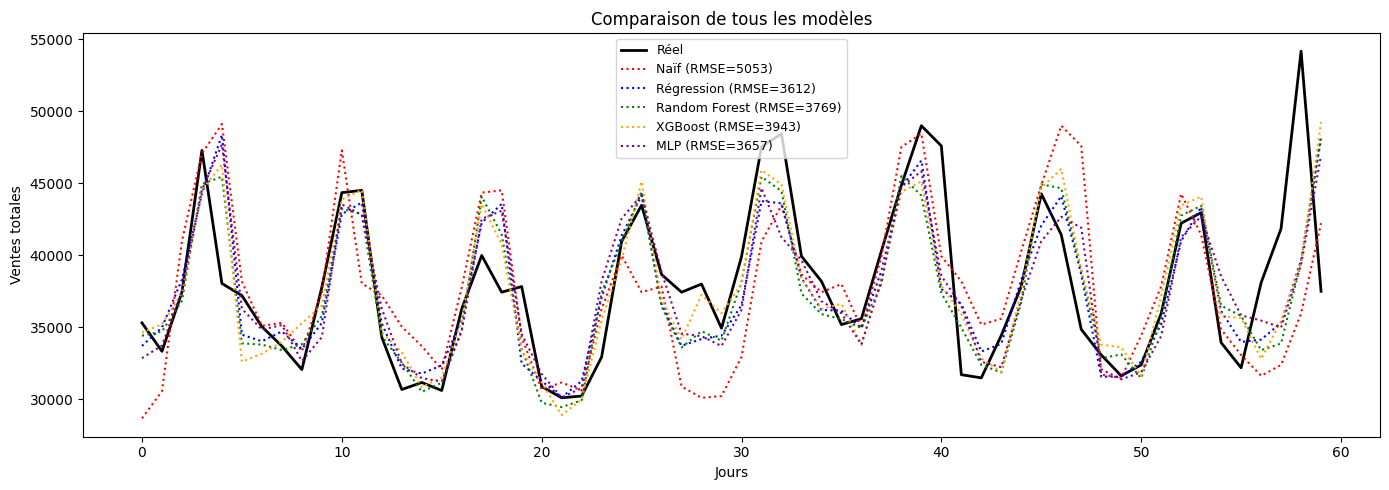

In [18]:
n = 60  # nombre de points à afficher

plt.figure(figsize=(14, 5))
plt.plot(y_test.values[:n], label="Réel", color="black",      linewidth=2)
plt.plot(X_test["lag_7"].values[:n], label=f"Naïf (RMSE={rmse_naif:.0f})", color="red", linestyle="dotted")
plt.plot(pred_rl[:n], label=f"Régression (RMSE={rmse_rl:.0f})", color="blue",  linestyle="dotted")
plt.plot(pred_rf[:n], label=f"Random Forest (RMSE={rmse_rf:.0f})", color="green",  linestyle="dotted")
plt.plot(pred_xgb[:n], label=f"XGBoost (RMSE={rmse_xgb:.0f})", color="orange", linestyle="dotted")
plt.plot(pred_mlp[:n], label=f"MLP (RMSE={rmse_mlp:.0f})", color="purple", linestyle="dotted")

plt.title("Comparaison de tous les modèles")
plt.xlabel("Jours")
plt.ylabel("Ventes totales")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

---

## Export de la régression linéaire pour streamlit

In [20]:
import joblib

rl_final = LinearRegression()
rl_final.fit(X, y)

joblib.dump(rl_final, "modele_regression.pkl")
joblib.dump(features, "features_regression.pkl")
daily.to_csv("daily_regression.csv", index=False)
daily.tail(28).to_csv("28derniersjours_regression.csv", index=False)

print("Fichiers sauvegardés")

Fichiers sauvegardés
